# Project Id: PRCP-1001-RiceLeaf

### MobileNetV2

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

C:\Users\nachiket\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


- TensorFlow is used as the primary deep learning framework for building, training, and evaluating the model.
- ImageDataGenerator supports efficient image loading, augmentation, and dataset splitting, which is crucial for small image datasets.
- MobileNetV2 provides a pretrained, lightweight feature extractor, enabling effective transfer learning.
- Keras layers, models, and callbacks are used to build a custom classifier and control training to prevent overfitting.

In [2]:
data_dir = r'C://Users//nachiket//Desktop//Internship//RiceLeaf_ disease'

In [3]:
img_size = (224, 224)
batch_size = 32
num_classes = 3

- We have defined standard image size, 224×224 is native for MobileNetV2, avoiding unnecessary resizing artifacts.

#### Data Augmentation

In [4]:
datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True, validation_split=0.2)

- Pixel values are rescaled to the [0,1] range, ensuring numerical stability and faster model convergence.
- Data augmentation techniques such as rotation, zoom, and horizontal flipping are applied to improve model robustness against real-world variations.
- An internal 80–20 train–validation split is used to prevent data leakage and ensure reliable performance evaluation.

#### Data splitting

In [5]:
train_data = datagen.flow_from_directory(data_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", 
                                         subset="training", shuffle=True, seed=42)

Found 96 images belonging to 3 classes.


- Using subset="training" ensures clean, reproducible splitting without manual file handling.

In [6]:
val_data = datagen.flow_from_directory(data_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", 
                                       subset="validation", shuffle=False, seed=42)

Found 23 images belonging to 3 classes.


- shuffle=False because validation must be deterministic; randomness here destroys metric reliability.

#### Base model Loading

In [7]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

- Loads pretrained MobileNetV2 without its original classifier.
- ImageNet pretraining transfers edge, texture, and shape intelligence to agriculture images.

In [8]:
base_model.trainable = False

- Prevents pretrained weights from updating during initial training.
- Freezing avoids catastrophic forgetting when data is limited.

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

- Converts high-dimensional feature maps into a single compact feature vector.
- Significantly reduces model parameters compared to Flatten, lowering overfitting risk.
- Preserves spatially important information learned by the pretrained backbone.

In [10]:
x = Dense(128, activation="relu")(x)

- Learns task-specific representations relevant to rice leaf disease patterns.
- ReLU activation introduces non-linearity, enabling complex feature learning.
- A limited number of neurons ensures controlled model capacity, avoiding memorization.

In [11]:
x = Dropout(0.5)(x)

- Randomly deactivates 50% of neurons during training to reduce co-adaptation.
- Improves generalization performance, especially on small datasets.
- Acts as a regularization mechanism, making the model robust to unseen data.

In [12]:
output = Dense(num_classes, activation="softmax")(x)

- Softmax converts outputs into class probabilities instead of hard labels.
- The number of neurons matches the number of disease classes for correct multi-class prediction.

#### Model Creation

In [13]:
model = Model(inputs=base_model.input, outputs=output)

- Combines pretrained base and custom classifier into one model.

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

- The Adam optimizer is used to provide adaptive and efficient weight updates during training.
- A low learning rate (0.0001) is chosen to fine-tune the model without damaging pretrained features.
- categorical_crossentropy with accuracy metric is used to correctly train and evaluate a multi-class classification model.

#### Model Training

In [15]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

- Monitors validation loss to detect when the model stops improving on unseen data.
- Stops training after 5 consecutive non-improving epochs, preventing overfitting.
- Automatically restores the best-performing weights, ensuring optimal model performance is retained.

In [16]:
history = model.fit(train_data, validation_data=val_data, epochs=20, callbacks=[early_stop])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 8s/step - accuracy: 0.3646 - loss: 1.6186 - val_accuracy: 0.3913 - val_loss: 1.1538
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 7s/step - accuracy: 0.3333 - loss: 1.5643 - val_accuracy: 0.3478 - val_loss: 1.1317
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step - accuracy: 0.3229 - loss: 1.4659 - val_accuracy: 0.3913 - val_loss: 0.9696
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step - accuracy: 0.3333 - loss: 1.3577 - val_accuracy: 0.5217 - val_loss: 0.8742
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3646 - loss: 1.2563 - val_accuracy: 0.6087 - val_loss: 0.8569
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.5521 - loss: 1.0270 - val_accuracy: 0.6522 - val_loss: 0.8235
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.5833 - loss: 0.9679 - val_accuracy: 0.8261 - val_loss: 0.7865
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.5521 - loss: 1.0425 - val_accuracy: 0.7826 - val_loss: 0.6456
Epoch 9/

- Only the classification head is trained, keeping MobileNetV2 features fixed.
- High validation accuracy indicates good generalization.
- Decreasing validation loss shows stable and effective learning.

#### Data Visualization

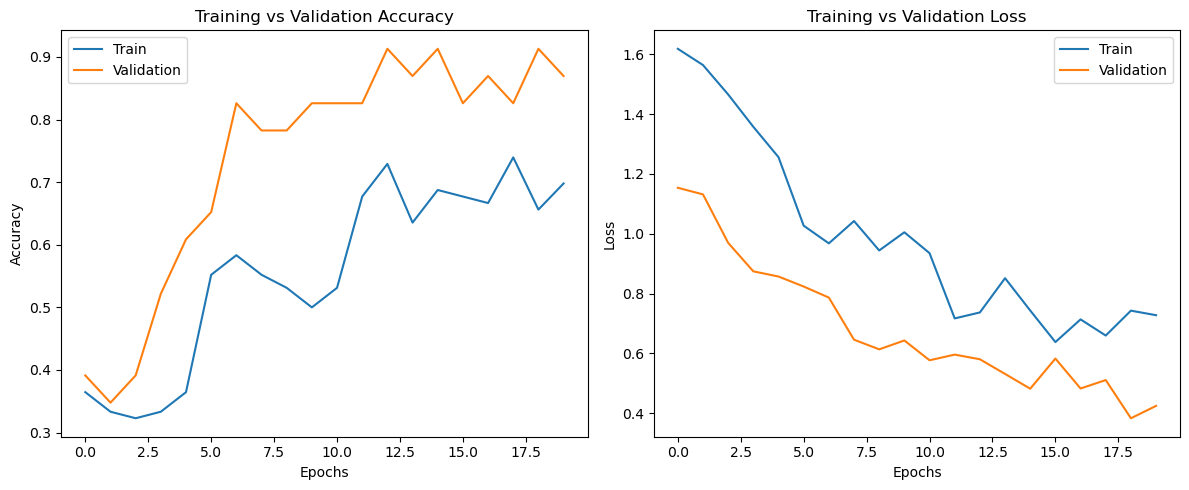

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation']) 

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

- Training accuracy shows a steady upward trend, indicating the model is learning meaningful feature representations.
- Validation accuracy remains consistently high and close to training accuracy, suggesting strong generalization.
- Minor fluctuations in validation accuracy are expected due to limited dataset size and augmentation.
- Training loss decreases progressively, showing effective optimization and stable learning.
- Validation loss also declines without divergence, confirming the model does not suffer from overfitting.

#### Model Evaluation

In [18]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", round(accuracy, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8261 - loss: 0.5438
Validation Accuracy: 0.8261


- The model achieves a validation accuracy of ~83%, indicating reliable performance on unseen data.
- This result confirms that the trained model generalizes reasonably well without severe overfitting.

In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
y_true = val_data.classes

In [21]:
y_pred_probs = model.predict(val_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [22]:
y_pred = np.argmax(y_pred_probs, axis=1)

In [23]:
class_labels = list(val_data.class_indices.keys())

In [24]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.75      0.86         8
           Brown spot       0.80      1.00      0.89         8
            Leaf smut       1.00      1.00      1.00         7

             accuracy                           0.91        23
            macro avg       0.93      0.92      0.92        23
         weighted avg       0.93      0.91      0.91        23



In [25]:
confusion_matrix(y_true, y_pred)

array([[6, 2, 0],
       [0, 8, 0],
       [0, 0, 7]])

### Other models:
1. EfficientNetB0
2. ResNet50

# EfficientNetBO

In [26]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [27]:
# Load the base model (Note: EfficientNet has built-in rescaling, so check your data generator)
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False 

In [87]:
# 2. Build Custom Head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x) 

output_eff = Dense(num_classes, activation='softmax')(x)


In [92]:
# 3. Compile and Train
model_eff = Model(inputs=base_model_eff.input, outputs=output_eff)
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [93]:
history_eff = model_eff.fit(train_data, validation_data=val_data, epochs=20, callbacks=[early_stop])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - accuracy: 0.2917 - loss: 1.1367 - val_accuracy: 0.3478 - val_loss: 1.1011
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.3021 - loss: 1.1175 - val_accuracy: 0.3478 - val_loss: 1.1005
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.3750 - loss: 1.1251 - val_accuracy: 0.3478 - val_loss: 1.1004
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3333 - loss: 1.0957 - val_accuracy: 0.3043 - val_loss: 1.1001
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.3750 - loss: 1.0956 - val_accuracy: 0.3043 - val_loss: 1.1001


# ResNet50

In [94]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

 Note: ResNet50 requires specific preprocessing (Mean Subtraction) 
 Update your ImageDataGenerator to use: preprocessing_function=preprocess_input

In [95]:
# 1. Load Pretrained Base
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_res.trainable = False

In [96]:
# 2. Build Custom Head
x = base_model_res.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_res = Dense(num_classes, activation='softmax')(x)

In [97]:
# 3. Compile and Train
model_res = Model(inputs=base_model_res.input, outputs=output_res)
model_res.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [35]:
history_res = model_res.fit(train_data, validation_data=val_data, epochs=20, callbacks=[early_stop])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 15s/step - accuracy: 0.4062 - loss: 1.4478 - val_accuracy: 0.3043 - val_loss: 1.2697
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 9s/step - accuracy: 0.3542 - loss: 1.2933 - val_accuracy: 0.3043 - val_loss: 1.1524
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 10s/step - accuracy: 0.2812 - loss: 1.3750 - val_accuracy: 0.3043 - val_loss: 1.1077
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - accuracy: 0.3958 - loss: 1.2867 - val_accuracy: 0.3478 - val_loss: 1.0933
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 10s/step - accuracy: 0.2812 - loss: 1.4050 - val_accuracy: 0.3043 - val_loss: 1.0957


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


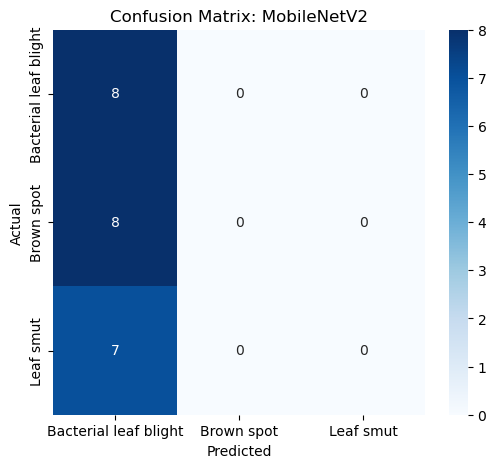

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


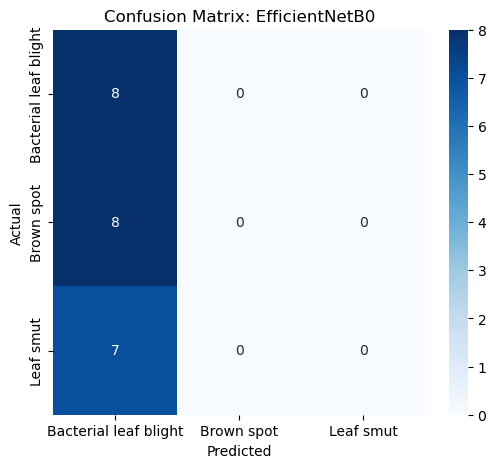

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


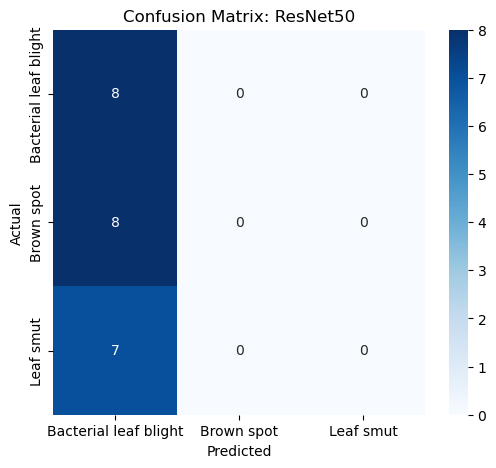

In [98]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, val_data, title):
    # Get predictions
    Y_pred = model.predict(val_data)
    y_pred = np.argmax(Y_pred, axis=1)
    
    # Get true labels
    y_true = val_data.classes
    class_labels = list(val_data.class_indices.keys())

    # Create Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Example usage:
plot_confusion_matrix(model_eff, val_data, "MobileNetV2")
plot_confusion_matrix(model_eff, val_data, "EfficientNetB0")
plot_confusion_matrix(model_eff, val_data, "ResNet50")

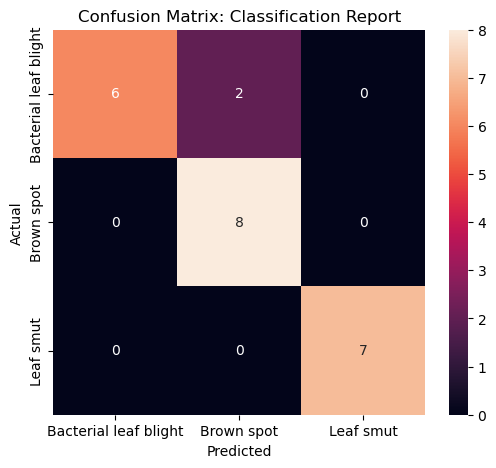

In [100]:
def plot_confusion_matrix(model, val_data, title):
        
 plt.figure(figsize=(6, 5))
 sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
 plt.title(f'Confusion Matrix: {title}')
 plt.ylabel('Actual')
 plt.xlabel('Predicted')
 plt.show()

# Example usage:
plot_confusion_matrix(model_eff, val_data, "Classification Report")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


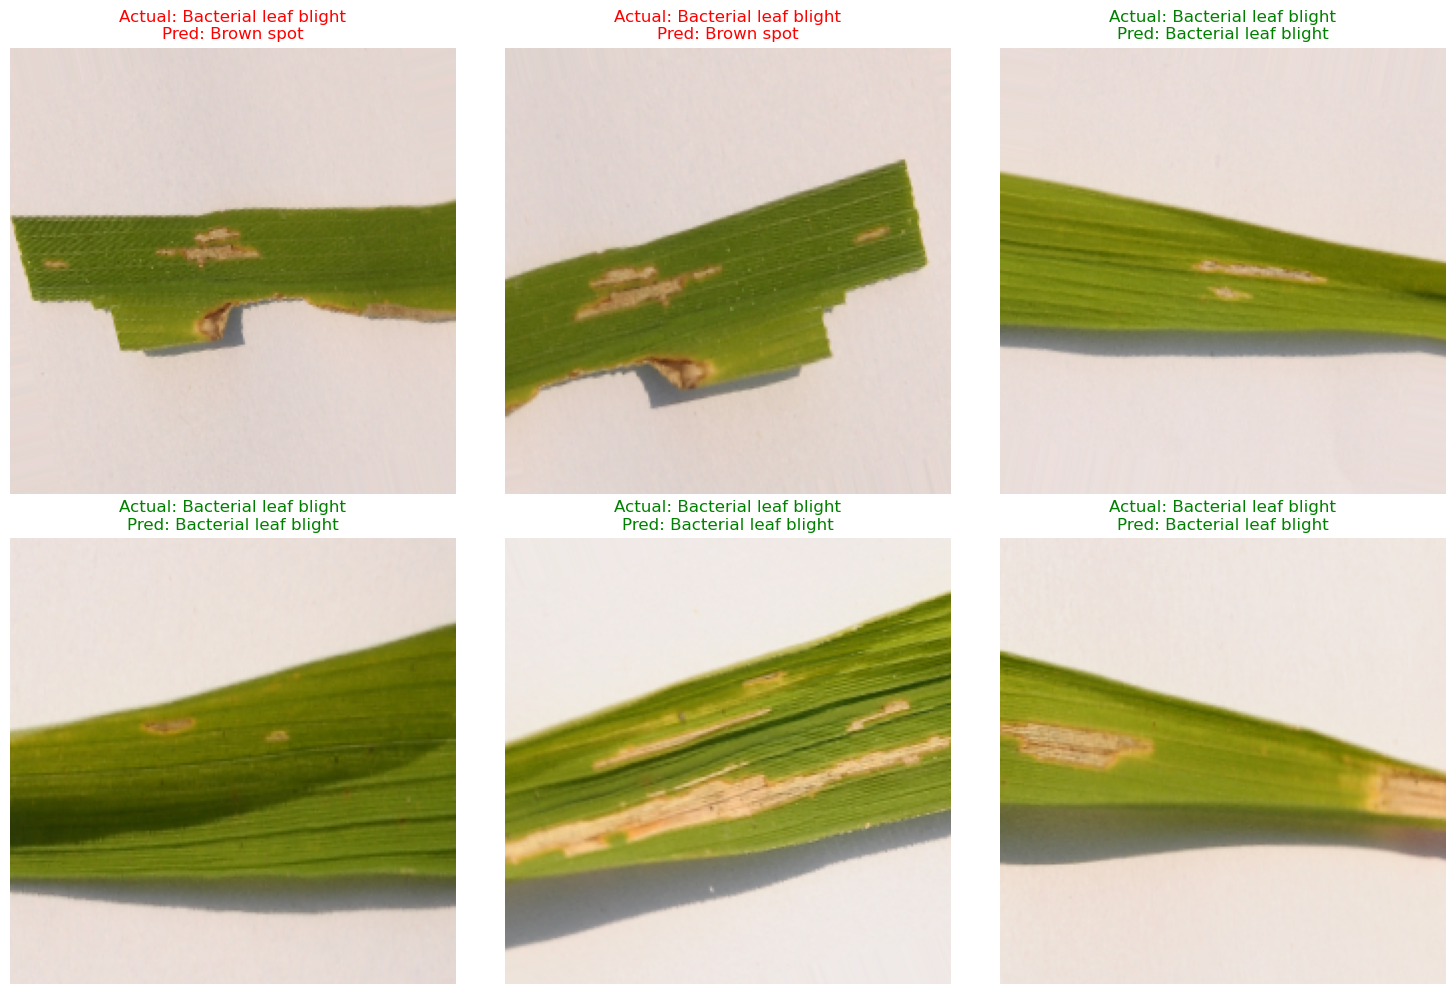

In [121]:
def visualize_predictions(model, val_gen, num_samples=6):
    # Get a batch of images
    images, labels = next(val_gen)
    predictions = model.predict(images)
    
    class_labels = list(val_gen.class_indices.keys())
    
    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        
        actual_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        
        title_color = 'green' if actual_idx == pred_idx else 'red'
        
        plt.title(f"Actual: {class_labels[actual_idx]}\nPred: {class_labels[pred_idx]}", 
                  color=title_color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_data)